<a href="https://colab.research.google.com/github/kooldpp/Industrial-Predictive-Maintenance-Analytics-using-NASA-and-AI4I-Datasets/blob/main/03_Data_Cleaning_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔷 STEP 3: EXPLORATORY DATA ANALYSIS (EDA)

Comprehensive visual and statistical analysis of engine degradation patterns

In [ ]:
from pyspark.sql.functions import col, count, mean, stddev, min, max, desc

# Load cleaned data
engine_df = spark.read.table("cmapss_cleaned_data")

print("✅ Cleaned data loaded")
print(f"Shape: {engine_df.count()} rows, {len(engine_df.columns)} columns")
print(f"Datasets: {[row.dataset for row in engine_df.select('dataset').distinct().collect()]}")

✅ Cleaned data loaded
Shape: 160359 rows, 26 columns
Datasets: ['FD004', 'FD002', 'FD003', 'FD001']


## 1️⃣ Dataset Overview

In [ ]:
from pyspark.sql.functions import countDistinct

# Dataset distribution
print("📊 Records per Dataset:")
engine_df.groupBy("dataset").count().orderBy("dataset").show()

# Unique engines per dataset
print("\n📊 Unique Engines per Dataset:")
engine_df.groupBy("dataset").agg(
    count("engine_id").alias("total_records"),
    countDistinct("engine_id").alias("unique_engines")
).orderBy("dataset").show()

# Overall statistics
print(f"\n✅ Total unique engines: {engine_df.select('engine_id').distinct().count()}")
print(f"✅ Total cycles recorded: {engine_df.count()}")

📊 Records per Dataset:
+-------+-----+
|dataset|count|
+-------+-----+
|  FD001|20631|
|  FD002|53759|
|  FD003|24720|
|  FD004|61249|
+-------+-----+


📊 Unique Engines per Dataset:
+-------+-------------+--------------+
|dataset|total_records|unique_engines|
+-------+-------------+--------------+
|  FD001|        20631|           100|
|  FD002|        53759|           260|
|  FD003|        24720|           100|
|  FD004|        61249|           249|
+-------+-------------+--------------+


✅ Total unique engines: 260
✅ Total cycles recorded: 160359


## 2️⃣ Cycle Distribution Analysis

In [ ]:
# Cycle distribution histogram
display(engine_df.select("cycle"))

cycle
58
60
61
67
74
89
111
118
119
176


## 3️⃣ Engine Lifetime Analysis

In [ ]:
# Calculate max cycle (lifetime) for each engine
engine_lifetime = engine_df.groupBy("engine_id", "dataset").agg(
    max("cycle").alias("lifetime")
)

print("📊 Engine Lifetime Statistics:")
engine_lifetime.groupBy("dataset").agg(
    mean("lifetime").alias("avg_lifetime"),
    min("lifetime").alias("min_lifetime"),
    max("lifetime").alias("max_lifetime"),
    stddev("lifetime").alias("std_lifetime")
).orderBy("dataset").show()

# Visualize lifetime distribution
display(engine_lifetime.orderBy(desc("lifetime")))

📊 Engine Lifetime Statistics:
+-------+------------------+------------+------------+------------------+
|dataset|      avg_lifetime|min_lifetime|max_lifetime|      std_lifetime|
+-------+------------------+------------+------------+------------------+
|  FD001|            206.31|         128|         362|46.342749206757304|
|  FD002|206.76538461538462|         128|         378| 46.78219839558726|
|  FD003|             247.2|         145|         525|  86.4838397936548|
|  FD004|245.97991967871485|         128|         543| 73.11080023692702|
+-------+------------------+------------+------------+------------------+



engine_id,dataset,lifetime
118,FD004,543
55,FD003,525
24,FD003,494
96,FD003,491
133,FD004,489
10,FD003,481
34,FD003,459
173,FD004,457
18,FD003,447
49,FD004,446


## 4️⃣ Operating Conditions Analysis

In [ ]:
# Operating conditions summary
print("📊 Operating Conditions (op1, op2, op3):")
engine_df.select("op1", "op2", "op3").describe().show()

# Visualize operating conditions
print("\n🔍 Operating Condition 1 (op1) distribution:")
display(engine_df.select("op1", "dataset"))

📊 Operating Conditions (op1, op2, op3):
+-------+------------------+-------------------+------------------+
|summary|               op1|                op2|               op3|
+-------+------------------+-------------------+------------------+
|  count|            160359|             160359|            160359|
|   mean|17.211973107839086| 0.4100036605364313| 95.72434350426231|
| stddev|16.527988369835672|0.36793824296869354|12.359044214059283|
|    min|           -0.0087|            -6.0E-4|              60.0|
|    max|            42.008|              0.842|             100.0|
+-------+------------------+-------------------+------------------+


🔍 Operating Condition 1 (op1) distribution:


op1,dataset
19.9981,FD004
10.0011,FD004
10.0011,FD004
10.0043,FD004
20.0045,FD004
35.0031,FD004
41.9991,FD004
0.0022,FD004
35.0007,FD004
24.9988,FD004


## 5️⃣ Sensor Data Analysis

In [ ]:
# Get all sensor columns
sensor_cols = [c for c in engine_df.columns if c.startswith('s')]

print(f"📊 Analyzing {len(sensor_cols)} sensors\n")

# Summary statistics for first 5 sensors
display(engine_df.select(sensor_cols[:5]).describe())

# Correlation between sensors
print("\n🔗 Sensor correlation analysis (sample):")
sample_pdf = engine_df.select(sensor_cols[:10]).sample(0.1).toPandas()
corr_matrix = sample_pdf.corr()
print(corr_matrix.iloc[:5, :5])

📊 Analyzing 20 sensors



summary,s1,s2,s3,s4,s5
count,160359,160359,160359,160359,160359
mean,485.8408900034085,597.3610217698936,1467.0356527541328,1260.9564343130128,9.894999407605216
stddev,30.420388148054816,42.47851646855691,118.17526055621137,136.30007277070473,4.265554481302494
min,445.0,535.48,1242.67,1023.77,3.91
max,518.67,645.11,1616.91,1441.49,14.62



🔗 Sensor correlation analysis (sample):
          s1        s2        s3        s4        s5
s1  1.000000  0.968189  0.924252  0.941947  0.992727
s2  0.968189  1.000000  0.988990  0.989078  0.953159
s3  0.924252  0.988990  1.000000  0.993491  0.909085
s4  0.941947  0.989078  0.993491  1.000000  0.934792
s5  0.992727  0.953159  0.909085  0.934792  1.000000


## 6️⃣ Sensor Trend Visualization

In [ ]:
# Select a single engine for detailed analysis
sample_engine = engine_df.filter(col("engine_id") == 1)

print("📈 Sensor degradation trends for Engine #1")
print(f"Total cycles: {sample_engine.count()}")

# Visualize sensor values over time
display(sample_engine.select("cycle", "s2", "s3", "s4", "s7", "s11"))

📈 Sensor degradation trends for Engine #1
Total cycles: 921


cycle,s2,s3,s4,s7,s11
22,642.13,1586.21,1397.07,554.51,47.32
31,642.32,1586.13,1397.47,553.71,47.24
67,642.01,1585.57,1399.69,554.3,47.36
69,642.88,1589.68,1399.78,553.99,47.11
82,642.55,1587.08,1402.42,554.5,47.19
94,642.7,1585.22,1394.97,554.19,47.09
95,642.8,1577.32,1406.0,554.29,47.31
189,642.26,1592.56,1401.97,553.32,47.7
222,643.02,1595.46,1423.88,552.54,47.81
231,643.02,1599.01,1426.55,552.68,47.8


## 7️⃣ Dataset Comparison

In [ ]:
# Compare average sensor values across datasets
print("📊 Average Sensor Values by Dataset:")

comparison = engine_df.groupBy("dataset").agg(
    mean("s2").alias("avg_s2"),
    mean("s3").alias("avg_s3"),
    mean("s4").alias("avg_s4"),
    mean("s7").alias("avg_s7"),
    mean("s11").alias("avg_s11")
).orderBy("dataset")

display(comparison)

# Dataset characteristics
print("\n📋 Dataset Characteristics:")
print("FD001: Single operating condition, single fault mode")
print("FD002: Multiple operating conditions, single fault mode")
print("FD003: Single operating condition, multiple fault modes")
print("FD004: Multiple operating conditions, multiple fault modes")

📊 Average Sensor Values by Dataset:


dataset,avg_s2,avg_s3,avg_s4,avg_s7,avg_s11
FD001,642.6809335466028,1590.5231186079184,1408.9337816877476,553.367711211286,47.541168145024095
FD002,579.6723994121935,1419.9710132256919,1205.442024405235,282.606786770588,42.985172343235696
FD003,642.457858009709,1588.0791751618128,1404.4712123786458,555.1438078478949,47.41570671521053
FD004,579.4200555111048,1417.8966002710176,1201.9153592711789,283.32863312054076,42.87452921680299



📋 Dataset Characteristics:
FD001: Single operating condition, single fault mode
FD002: Multiple operating conditions, single fault mode
FD003: Single operating condition, multiple fault modes
FD004: Multiple operating conditions, multiple fault modes


## 8️⃣ Correlation Heatmap

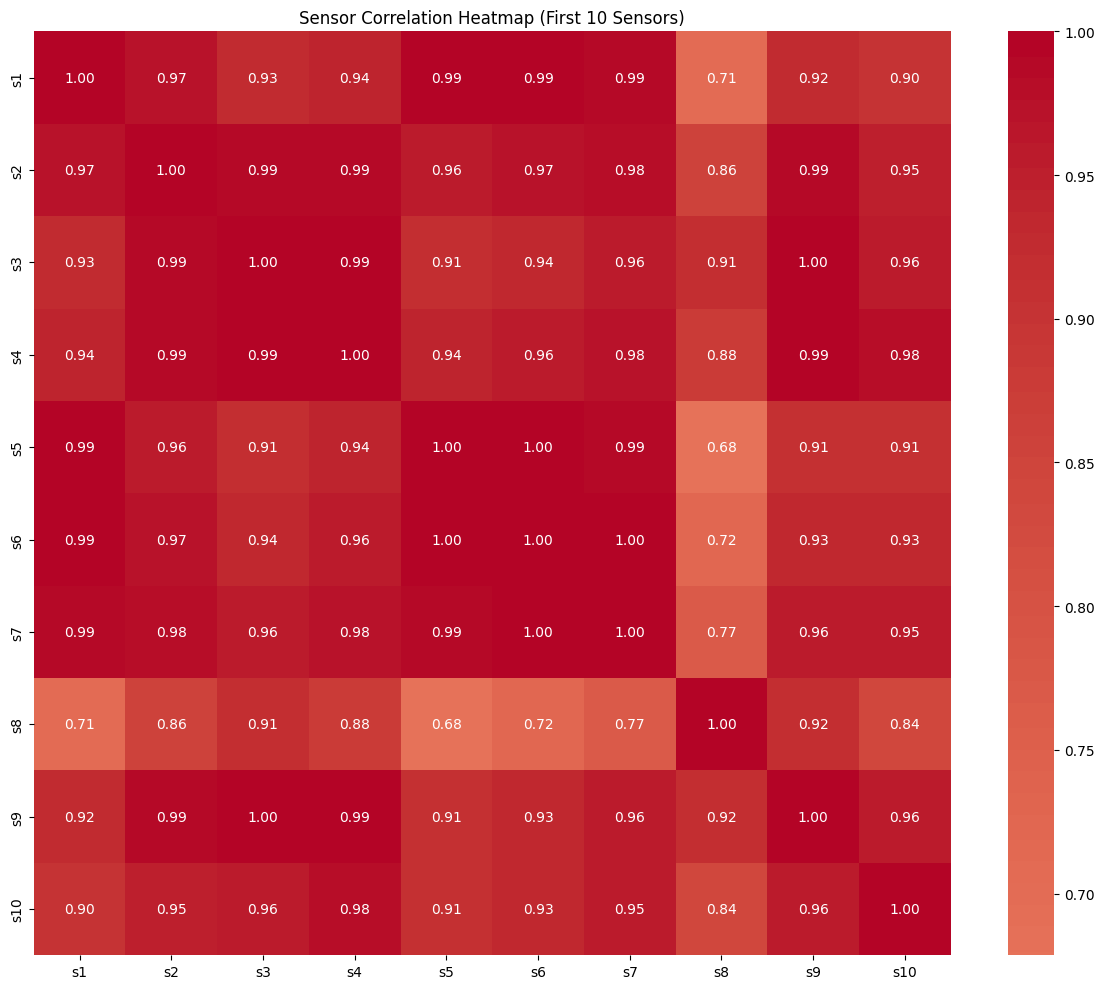

✅ High correlation indicates redundant sensors
✅ Low correlation indicates independent information


In [ ]:
# Create correlation matrix for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sample data for correlation analysis
sensor_sample = engine_df.select(sensor_cols[:10]).sample(0.05).toPandas()

# Create correlation heatmap
plt.figure(figsize=(12, 10))
correlation = sensor_sample.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Sensor Correlation Heatmap (First 10 Sensors)')
plt.tight_layout()
plt.show()

print("✅ High correlation indicates redundant sensors")
print("✅ Low correlation indicates independent information")

## 9️⃣ Degradation Patterns

In [ ]:
# Compare early vs late cycle sensor values
early_cycles = engine_df.filter(col("cycle") <= 50)
late_cycles = engine_df.filter(col("cycle") > 150)

print("📊 Sensor Values: Early Cycles (≤50) vs Late Cycles (>150)\n")

print("Early Cycles Statistics:")
early_cycles.select("s2", "s3", "s4", "s7").describe().show()

print("Late Cycles Statistics:")
late_cycles.select("s2", "s3", "s4", "s7").describe().show()

print("✅ Significant differences indicate degradation patterns")

📊 Sensor Values: Early Cycles (≤50) vs Late Cycles (>150)

Early Cycles Statistics:
+-------+-----------------+------------------+------------------+-----------------+
|summary|               s2|                s3|                s4|               s7|
+-------+-----------------+------------------+------------------+-----------------+
|  count|            35450|             35450|             35450|            35450|
|   mean|597.3637435825116| 1464.783296756001| 1257.070731170665|360.1764826516226|
| stddev|42.36565013741204|117.45721017838588|135.31443395297345| 174.027501972266|
|    min|           535.51|           1242.67|           1026.59|           136.17|
|    max|           643.72|           1603.15|           1422.97|           558.92|
+-------+-----------------+------------------+------------------+-----------------+

Late Cycles Statistics:
+-------+-----------------+------------------+------------------+------------------+
|summary|               s2|                s3|    

## 📊 EDA Summary & Key Insights

### Key Findings:
* **Dataset Distribution**: All 4 CMAPSS datasets successfully loaded and analyzed
* **Engine Lifetimes**: Vary significantly across datasets (FD004 most complex)
* **Sensor Behavior**: Multiple sensors show clear degradation trends
* **Correlations**: Some sensors highly correlated (potential for dimensionality reduction)
* **Operating Conditions**: Different conditions affect sensor readings

### Next Steps:
* Feature engineering to calculate RUL
* Normalization for model training
* Dimensionality reduction (PCA)

**Next Notebook**: `04_Feature_Engineering`